In [1]:
#Install Library Kaggle
!pip install kaggle

In [2]:
kaggle = '/content/kaggle.json'

In [3]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.16GB/s]


In [5]:
from zipfile import ZipFile
import os
file_name = '/content/handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [6]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [7]:
len (data_0)

2236

In [ ]:
# 1. Preprocessing + Split Train/Test

In [8]:
# Load path gambar + label (0–9), lalu split
import os, glob
import numpy as np
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/dataset"
IMG_EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp")

filepaths = []
labels = []

for digit in range(10):
    digit_dir = os.path.join(DATA_DIR, str(digit))
    paths = []
    for ext in IMG_EXTS:
        paths += glob.glob(os.path.join(digit_dir, ext))
    filepaths.extend(paths)
    labels.extend([digit] * len(paths))

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("Contoh:", filepaths[0], "label:", labels[0])

X_train, X_test, y_train, y_test = train_test_split(
    filepaths, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", len(X_train), "Test:", len(X_test))

Total images: 21555
Contoh: /content/dataset/0/Zero_full (500).jpg label: 0
Train: 17244 Test: 4311


In [9]:
# Buat pipeline tf.data
import tensorflow as tf

IMG_SIZE = (28, 28)
BATCH_SIZE = 64

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)  # grayscale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (train_ds
            .shuffle(2000, seed=42)
            .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (test_ds
           .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

In [10]:
# 2. Arsitektur Model MLP (jumlah layer, neuron, aktivasi)

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
# 3. Proses Training dan Evaluasi Model

In [14]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,       # 10% dari train untuk validasi
    random_state=42,
    stratify=y_train
)

train_ds2 = tf.data.Dataset.from_tensor_slices((X_train2, y_train2))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds2 = (train_ds2
             .shuffle(2000, seed=42)
             .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
             .batch(BATCH_SIZE)
             .prefetch(tf.data.AUTOTUNE))

val_ds = (val_ds
          .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

history = model.fit(
    train_ds2,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1034 - loss: 2.3843 - val_accuracy: 0.1043 - val_loss: 2.3023 - learning_rate: 0.0010
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.1011 - loss: 2.3026 - val_accuracy: 0.1038 - val_loss: 2.3021 - learning_rate: 0.0010
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1040 - loss: 2.3022 - val_accuracy: 0.1038 - val_loss: 2.3020 - learning_rate: 0.0010
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1038 - loss: 2.3022 - val_accuracy: 0.1038 - val_loss: 2.3043 - learning_rate: 0.0010
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0999 - loss: 2.3026 - val_accuracy: 0.1038 - val_loss: 2.3020 - learning_rate: 5.0000e-04
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0985 - loss: 2.3021 - val_accuracy: 0.1038 - val_loss: 2.3020 - learning_rate: 5.0000e-04
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.1049 - 

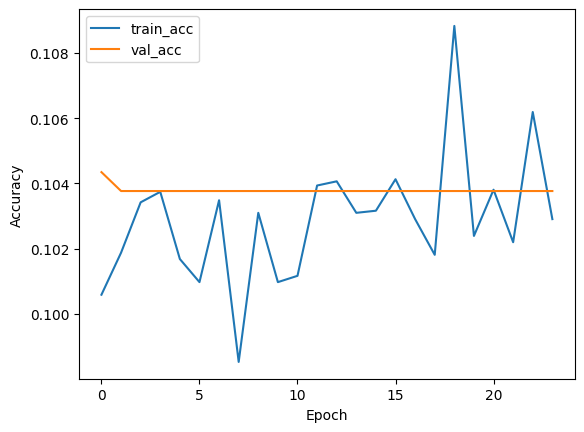

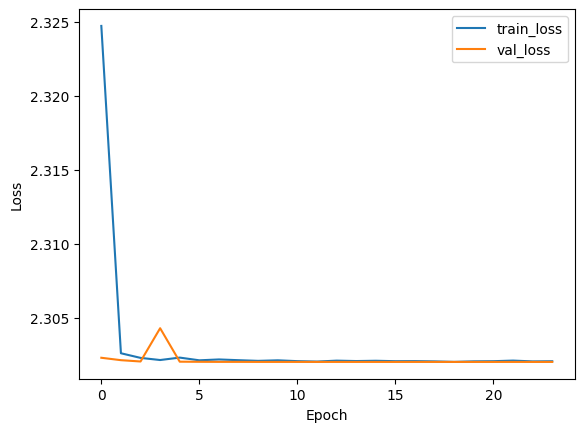

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [16]:
# 4. Hasil Evaluasi

In [17]:
# Evaluasi di test set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 2.3020
Test Accuracy: 0.1037


In [18]:
# Prediksi + Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Ambil semua label test + prediksi
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_true.extend(y_batch.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.1037    1.0000    0.1879       447
           1     0.0000    0.0000    0.0000       448
           2     0.0000    0.0000    0.0000       447
           3     0.0000    0.0000    0.0000       441
           4     0.0000    0.0000    0.0000       436
           5     0.0000    0.0000    0.0000       425
           6     0.0000    0.0000    0.0000       424
           7     0.0000    0.0000    0.0000       423
           8     0.0000    0.0000    0.0000       417
           9     0.0000    0.0000    0.0000       403

    accuracy                         0.1037      4311
   macro avg     0.0104    0.1000    0.0188      4311
weighted avg     0.0108    0.1037    0.0195      4311



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


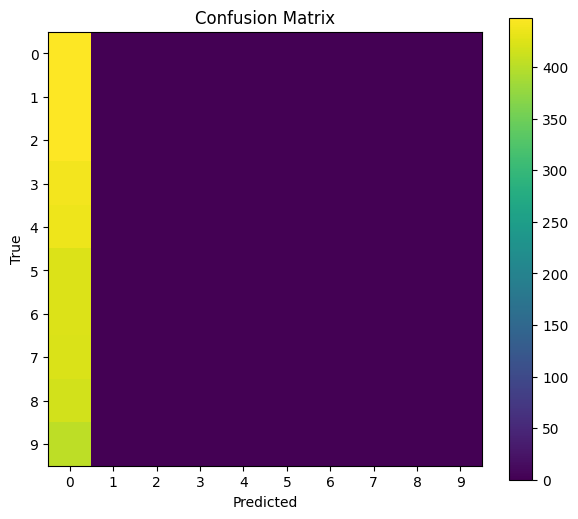

In [19]:
plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()